# Trabajo Practico de Análisis de Datos - CEIA

Integrantes:
- Yoharlyn Alvarez
- Sebastián Aragones
- Luis Paredes

# Consigna

- Consiga: Disponible en [Notion](https://www.notion.so/mis-notas/Trabajo-Practico-35525f24dbe28028a94fc41adfb1e27e?source=copy_link)

- **Fecha de entrega**: La presentación se debe entregar como máximo el día martes 16/6/2026
- Diapositivas: Antes de la clase 8 les compartiremos una presentación de Google Slides para que peguen
la información resumida en 5 diapositivas como máximo (pueden ser 5 + la carátula).
- Repositorio del codigo: [Github](https://github.com/LuisParedes1/TP-CEIA-Analisis-de-datos)

# Full TMDB Movies Dataset 2024
## Analisis Exploratorio de los datos
Dataset: [Full TMDB Movies Dataset 2024](https://www.kaggle.com/datasets/asaniczka/tmdb-movies-dataset-2023-930k-movies)

In [208]:
import pandas as pd
import kagglehub
import os
import matplotlib.pyplot as plt
import seaborn as sns
import missingno as msno
import numpy as np

directory_path: str = kagglehub.dataset_download("asaniczka/tmdb-movies-dataset-2023-930k-movies")

# Busco los archivos guardados en directory_path='/kaggle/input/tmdb-movies-dataset-2023-930k-movies/'
csv_files = [f for f in os.listdir(directory_path) if f.endswith('.csv')]

# Leo '/kaggle/input/tmdb-movies-dataset-2023-930k-movies/TMDB_movie_dataset_v11.csv'
df = pd.read_csv(os.path.join(directory_path, csv_files[0]))

df.head()

Using Colab cache for faster access to the 'tmdb-movies-dataset-2023-930k-movies' dataset.


,id,title,vote_average,vote_count,status,release_date,revenue,runtime,adult,backdrop_path,...,original_title,overview,popularity,poster_path,tagline,genres,production_companies,production_countries,spoken_languages,keywords
0,27205,Inception,8.364,34495,Released,2010-07-15,825532764,148,False,/8ZTVqvKDQ8emSGUEMjsS4yHAwrp.jpg,...,Inception,"Cobb, a skilled thief who commits corporate es...",83.952,/oYuLEt3zVCKq57qu2F8dT7NIa6f.jpg,Your mind is the scene of the crime.,"Action, Science Fiction, Adventure","Legendary Pictures, Syncopy, Warner Bros. Pict...","United Kingdom, United States of America","English, French, Japanese, Swahili","rescue, mission, dream, airplane, paris, franc..."
1,157336,Interstellar,8.417,32571,Released,2014-11-05,701729206,169,False,/pbrkL804c8yAv3zBZR4QPEafpAR.jpg,...,Interstellar,The adventures of a group of explorers who mak...,140.241,/gEU2QniE6E77NI6lCU6MxlNBvIx.jpg,Mankind was born on Earth. It was never meant ...,"Adventure, Drama, Science Fiction","Legendary Pictures, Syncopy, Lynda Obst Produc...","United Kingdom, United States of America",English,"rescue, future, spacecraft, race against time,..."
2,155,The Dark Knight,8.512,30619,Released,2008-07-16,1004558444,152,False,/nMKdUUepR0i5zn0y1T4CsSB5chy.jpg,...,The Dark Knight,Batman raises the stakes in his war on crime. ...,130.643,/qJ2tW6WMUDux911r6m7haRef0WH.jpg,Welcome to a world without rules.,"Drama, Action, Crime, Thriller","DC Comics, Legendary Pictures, Syncopy, Isobel...","United Kingdom, United States of America","English, Mandarin","joker, sadism, chaos, secret identity, crime f..."
3,19995,Avatar,7.573,29815,Released,2009-12-15,2923706026,162,False,/vL5LR6WdxWPjLPFRLe133jXWsh5.jpg,...,Avatar,"In the 22nd century, a paraplegic Marine is di...",79.932,/kyeqWdyUXW608qlYkRqosgbbJyK.jpg,Enter the world of Pandora.,"Action, Adventure, Fantasy, Science Fiction","Dune Entertainment, Lightstorm Entertainment, ...","United States of America, United Kingdom","English, Spanish","future, society, culture clash, space travel, ..."
4,24428,The Avengers,7.710,29166,Released,2012-04-25,1518815515,143,False,/9BBTo63ANSmhC4e6r62OJFuK2GL.jpg,...,The Avengers,When an unexpected enemy emerges and threatens...,98.082,/RYMX2wcKCBAr24UyPD7xwmjaTn.jpg,Some assembly required.,"Science Fiction, Action, Adventure",Marvel Studios,United States of America,"English, Hindi, Russian","new york city, superhero, shield, based on com..."


In [209]:
df.shape

(1443026, 24)

In [210]:
df.columns

Index(['id', 'title', 'vote_average', 'vote_count', 'status', 'release_date',
       'revenue', 'runtime', 'adult', 'backdrop_path', 'budget', 'homepage',
       'imdb_id', 'original_language', 'original_title', 'overview',
       'popularity', 'poster_path', 'tagline', 'genres',
       'production_companies', 'production_countries', 'spoken_languages',
       'keywords'],
      dtype='object')

In [211]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1443026 entries, 0 to 1443025
Data columns (total 24 columns):
 #   Column                Non-Null Count    Dtype  
---  ------                --------------    -----  
 0   id                    1443026 non-null  int64  
 1   title                 1443007 non-null  object 
 2   vote_average          1443026 non-null  float64
 3   vote_count            1443026 non-null  int64  
 4   status                1443026 non-null  object 
 5   release_date          1116024 non-null  object 
 6   revenue               1443026 non-null  int64  
 7   runtime               1443026 non-null  int64  
 8   adult                 1443026 non-null  bool   
 9   backdrop_path         356215 non-null   object 
 10  budget                1443026 non-null  int64  
 11  homepage              147968 non-null   object 
 12  imdb_id               673189 non-null   object 
 13  original_language     1443026 non-null  object 
 14  original_title        1443007 non-

In [212]:
df.iloc[0]

,0
id,27205
title,Inception
vote_average,8.364
vote_count,34495
status,Released
release_date,2010-07-15
revenue,825532764
runtime,148
adult,False
backdrop_path,/8ZTVqvKDQ8emSGUEMjsS4yHAwrp.jpg


Iniciamos con la identificación de datos faltantes e incorrectos para que nos ayude a plantear un problema, teniendo una cantidad relevante de datos que contribuyan al entrenamiento del modelo.

In [213]:

df.isna().sum()

,0
id,0
title,19
vote_average,0
vote_count,0
status,0
release_date,327002
revenue,0
runtime,0
adult,0
backdrop_path,1086811


In [214]:
df.isna().mean().round(4)*100

,0
id,0.00
title,0.00
vote_average,0.00
vote_count,0.00
status,0.00
release_date,22.66
revenue,0.00
runtime,0.00
adult,0.00
backdrop_path,75.31


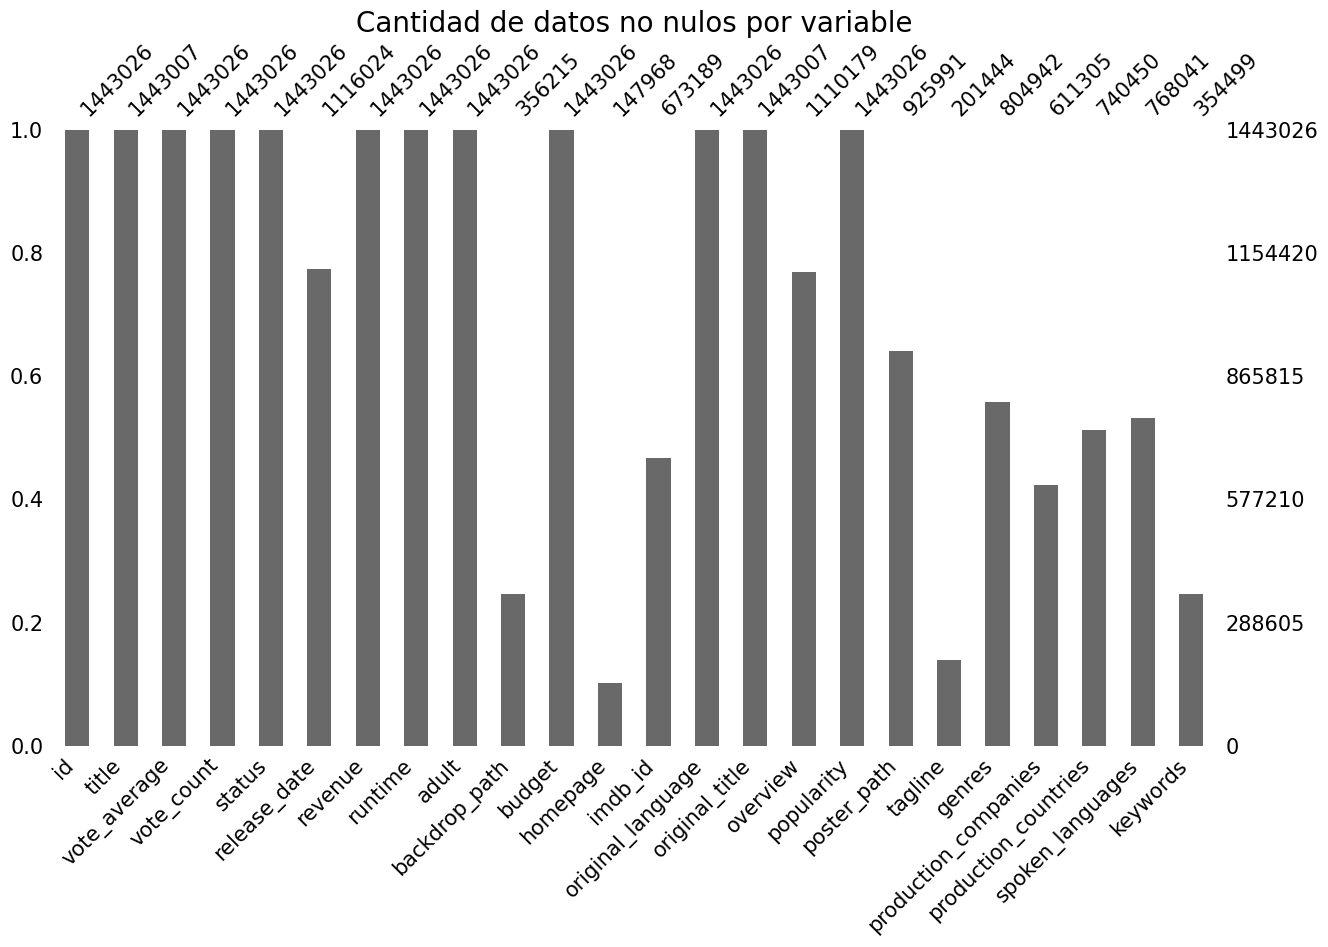

In [215]:
msno.bar(df, fontsize=15, figsize=(15,8))
plt.title("Cantidad de datos no nulos por variable", fontsize=20)
plt.show()

<Axes: >

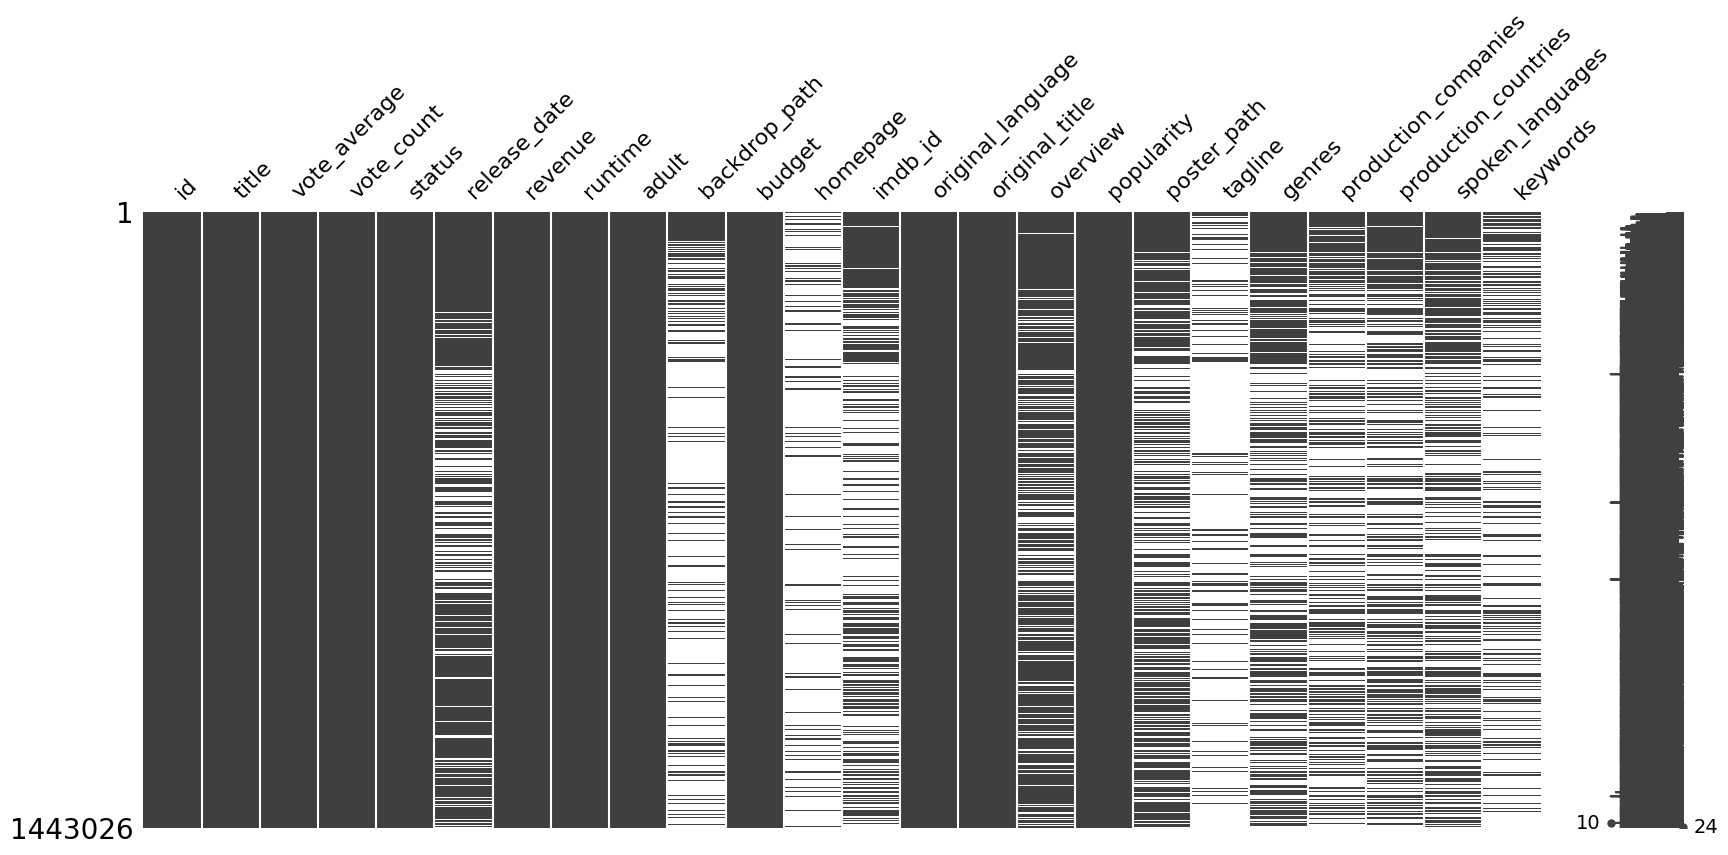

In [216]:
msno.matrix(df, figsize=(20,8))

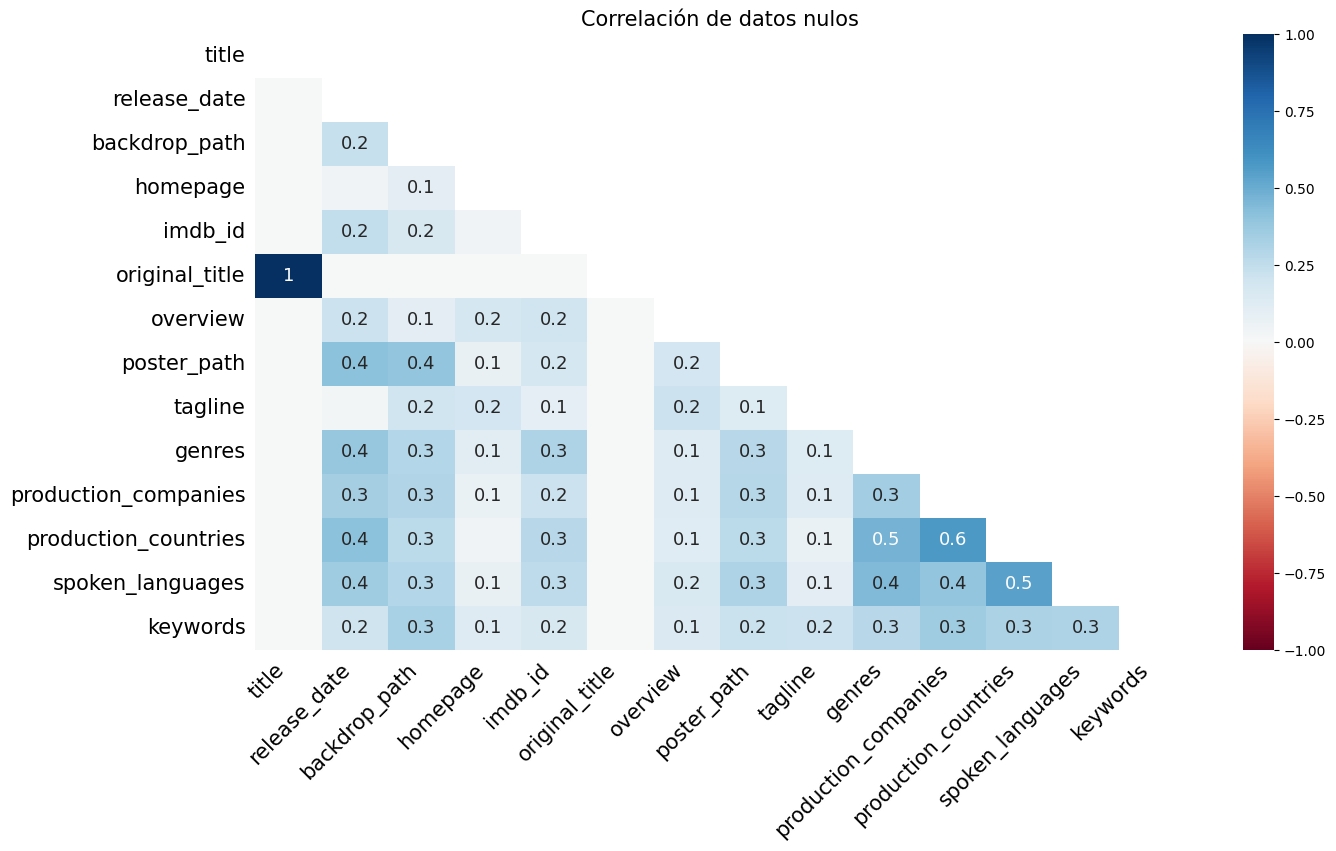

In [217]:
msno.heatmap(df, fontsize=15, figsize=(15,8))
plt.title("Correlación de datos nulos", fontsize=15)
plt.show()

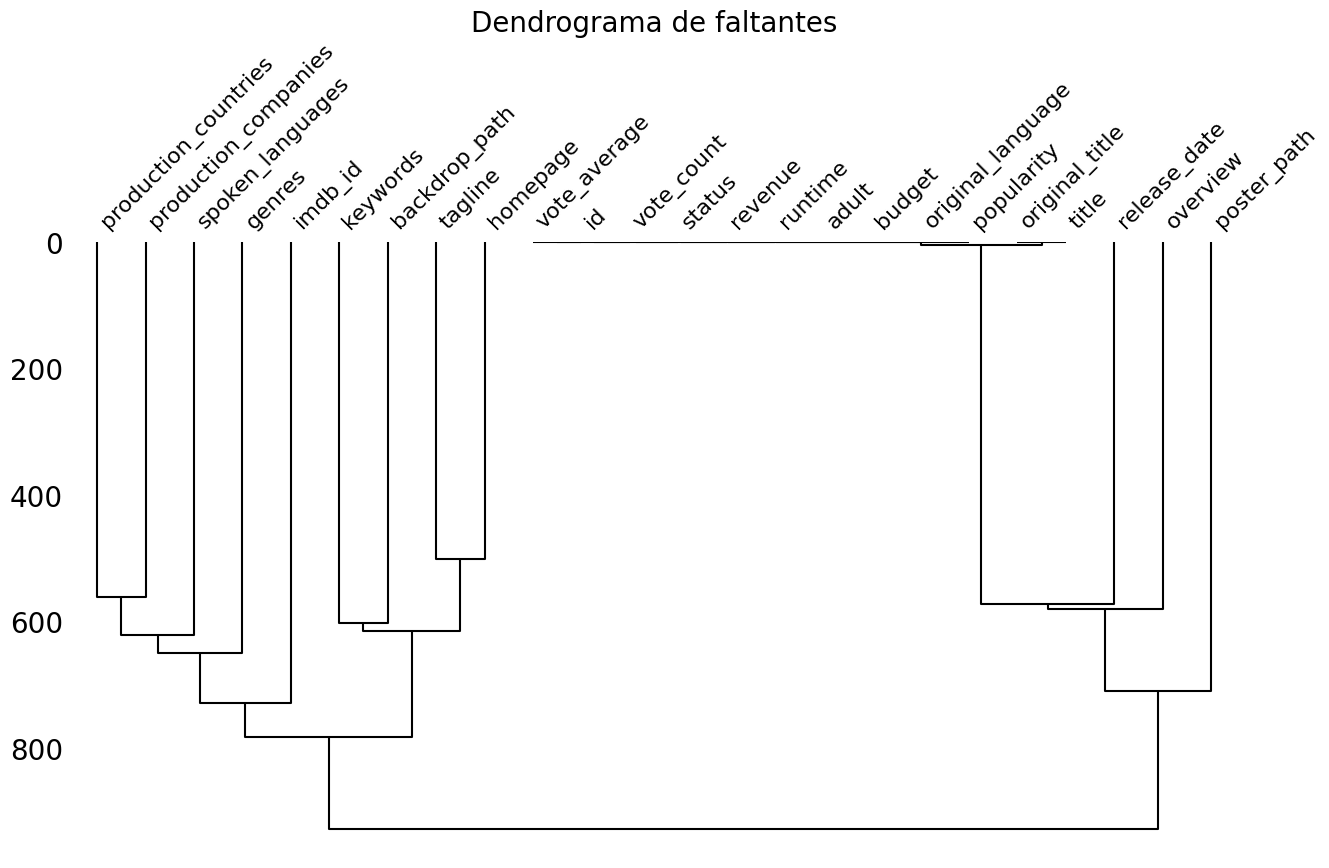

In [218]:
msno.dendrogram(df, figsize=(15,8))
plt.title('Dendrograma de faltantes', fontsize=20)
plt.show()

In [219]:
status_counts = df['status'].value_counts()
status_counts

,count
status,
Released,1389939
In Production,23974
Post Production,15961
Planned,11948
Rumored,828
Canceled,376


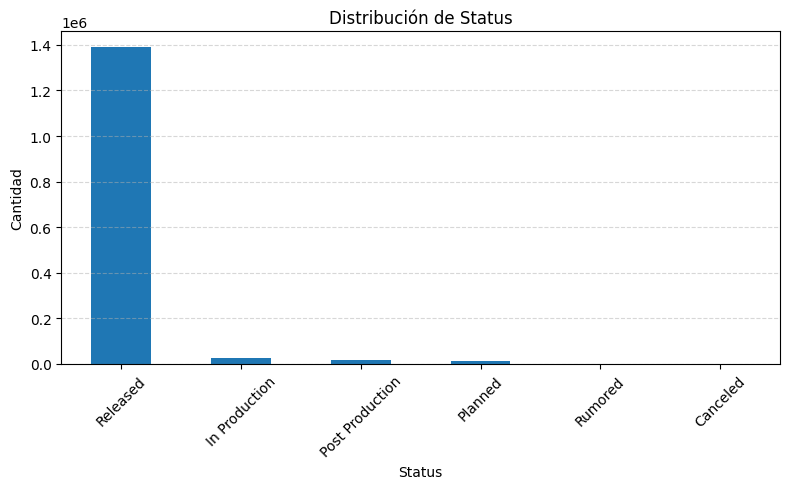

In [220]:
plt.figure(figsize=(8, 5))
status_counts.plot(kind='bar')

plt.title('Distribución de Status')
plt.xlabel('Status')
plt.ylabel('Cantidad')
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

In [221]:
df_release_date_null = df[df['release_date'].isna()]
release_date_null_status_counts = df_release_date_null['status'].value_counts()
release_date_null_status_counts

,count
status,
Released,296662
Post Production,10753
Planned,10164
In Production,8285
Rumored,780
Canceled,358


In [222]:
df['format_date'] = pd.to_datetime(df['release_date'], errors='coerce')
df['year'] = df['format_date'].dt.year.astype('Int64')

before_2000 = df[df['year'] < 2000]          # valid dates earlier than 2000
n_nulls = before_2000['budget'].isna().sum()  # swap 'budget' for your column

print(n_nulls)

0


In [223]:
df['format_date'] = pd.to_datetime(df['release_date'], errors='coerce')
df['year'] = df['format_date'].dt.year.astype('Int64')

df_format = df[(df['release_date'].isna()) & (df['year'] < 2000)]

df_format.shape

(0, 26)

Una de las columnas que utilizaremos para el problema que queremos plantear es **release_date** y por lo que vemos el **22.59%** de los datos tiene null en el valor de dicha columna.

Por lo que observamos, no encontramos un patrón para la ausencia de este valor. Inicialmente habíamos creído que las películas que no tenían este valor tendrían un valor de **status** diferente a "**released**", por lo cual no tendría una fecha establecida para su lanzamiento. Pero observamos algo completamente diferente a esto, la mayor cantidad de películas sin fecha de lanzamiento tienen status **released**. Por lo cual creemeos que para un gran porcentaje de las películas el tipo de causa de datos faltantes es **MCAR** y para un bajo porcentaje (las películas que aún no han salido) es de tipo **estructural**.

In [224]:
df['genres'].value_counts()

,count
genres,
Documentary,164733
Drama,125026
Comedy,66870
Animation,37115
Music,30057
...,...
"Family, Western, Adventure",1
"Science Fiction, Music, Action, Adventure, Comedy, Mystery",1
"Comedy, Crime, Thriller, Drama, Mystery",1


Observamos que en varias películas no posee un sólo género sino un listado de géneros. Más adelante tendremos que hacer un tratmiento a la muestra de datos para resolver esto.

In [225]:
unique_genres = (
    df['genres']
    .dropna()
    .str.split(',')
    .explode()
    .str.strip()
    .unique()
)

print(len(unique_genres))

19


In [226]:
unique_genres

array(['Action', 'Science Fiction', 'Adventure', 'Drama', 'Crime',
       'Thriller', 'Fantasy', 'Comedy', 'Romance', 'Western', 'Mystery',
       'War', 'Animation', 'Family', 'Horror', 'Music', 'History',
       'TV Movie', 'Documentary'], dtype=object)

In [227]:
df['adult'].value_counts()

,count
adult,
False,1300007
True,143019


In [228]:
df['production_companies'].value_counts()

,count
production_companies,
Evil Angel,3182
ONF | NFB,2451
BBC,2419
Metro-Goldwyn-Mayer,2051
Columbia Pictures,1959
...,...
"Johnson Production Group, Lifetime, Insight Film Studios, Ignite Entertainment",1
"Quantum Films, Star Cinema – ABS-CBN Film Productions, Skylight Films",1
"Shintoho Pictures, All In Entertainment",1


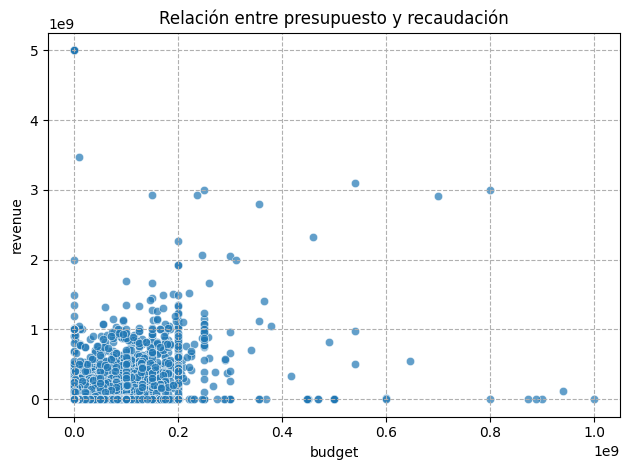

In [229]:
sns.scatterplot(data=df, x='budget', y='revenue', alpha=0.7)
plt.grid(ls='--')
plt.title('Relación entre presupuesto y recaudación')
plt.tight_layout()
plt.show()

In [230]:
min_budget = df['budget'].min()
max_budget = df['budget'].max()

print("Valor mínimo de presupuesto:", min_budget)
print("Valor máximo de presupuesto:", max_budget)

Valor mínimo de presupuesto: 0
Valor máximo de presupuesto: 999999999


In [231]:
min_revenue = df['revenue'].min()
max_revenue = df['revenue'].max()

print("Valor mínimo de recaudación:", min_revenue)
print("Valor máximo de recaudación:", max_revenue)

Valor mínimo de recaudación: -12
Valor máximo de recaudación: 4999999999


In [232]:
valid_budget_revenue = (df['budget'] > 0) & (df['revenue'] > 0)

valid_budget_revenue_count = valid_budget_revenue.sum()
valid_budget_revenue_percentage = valid_budget_revenue.mean() * 100

print("Cantidad de películas con presupuesto y recaudación mayores a 0:", valid_budget_revenue_count)
print(f"Porcentaje de películas con presupuesto y recaudación mayores a 0: {valid_budget_revenue_percentage:.2f}%")

Cantidad de películas con presupuesto y recaudación mayores a 0: 17658
Porcentaje de películas con presupuesto y recaudación mayores a 0: 1.22%


El problema inicial que que queríamos plantear estaba relacionado a identificar el éxito de una película en base a las ganancias que obtuvo, considerando que una película se considera financieramente exitosa cuando el revenue dupica el budget.

A pesar de que no existen valores nulos para estos campos, observamos que sí existen numerosas películas con valores 0 para algunos de estos campos.

De todo el dataset apenas un 1.22% posee el valor de ambas columnas.

Por esta razón no vemos factible continuar con este problema y buscamos seguir midiendo el éxito de la película pero en base a la votación.

In [233]:
min_budget = df['popularity'].min()
max_budget = df['popularity'].max()

print("Valor mínimo de presupuesto:", min_budget)
print("Valor máximo de presupuesto:", max_budget)

Valor mínimo de presupuesto: 0.0
Valor máximo de presupuesto: 2994.357


In [234]:
valid_popularity = (df['popularity'] > 0)

valid_popularity_count = valid_popularity.sum()
valid_popularity_percentage = valid_popularity.mean() * 100

print("Cantidad de películas con votación:", valid_popularity_count)
print(f"Porcentaje de películas con votación: {valid_popularity_percentage:.2f}%")

Cantidad de películas con votación: 1193297
Porcentaje de películas con votación: 82.69%


In [235]:
min_vote_count = df['vote_count'].min()
max_vote_count = df['vote_count'].max()

print("Valor mínimo de cantidad de votos:", min_vote_count)
print("Valor máximo de cantidad de votos:", max_vote_count)

Valor mínimo de cantidad de votos: 0
Valor máximo de cantidad de votos: 34495


In [236]:
min_vote_average = df['vote_average'].min()
max_vote_average = df['vote_average'].max()

print("Valor mínimo del promedio de votación:", min_vote_average)
print("Valor máximo del promedio de votación:", max_vote_average)

Valor mínimo del promedio de votación: 0.0
Valor máximo del promedio de votación: 10.0


In [237]:
valid_votes = (df['vote_count'] > 0) & (df['vote_average'] > 0)

valid_votes_count = valid_votes.sum()
valid_votes_percentage = valid_votes.mean() * 100

print("Cantidad de películas con votación:", valid_votes_count)
print(f"Porcentaje de películas con votación: {valid_votes_percentage:.2f}%")

Cantidad de películas con votación: 358480
Porcentaje de películas con votación: 24.84%


In [238]:
df_valid_movies = df[valid_votes]

In [239]:
df_valid_movies.isna().sum()

,0
id,0
title,1
vote_average,0
vote_count,0
status,0
release_date,8918
revenue,0
runtime,0
adult,0
backdrop_path,172994


In [240]:
df_valid_movies = df_valid_movies.dropna(subset=['release_date', 'genres'])

In [241]:
df_valid_movies.shape

(293350, 26)

In [242]:
genres_encoded = (
    df_valid_movies["genres"]
    .fillna("")
    .str.replace(", ", ",", regex=False)
    .str.get_dummies(sep=",")
)

genres_encoded = genres_encoded.add_prefix("genre_")

df_valid_movies = (
    df_valid_movies
    .join(genres_encoded)
    .drop(columns=["genres"])
)

df_valid_movies.shape

(293350, 44)

In [243]:
df_valid_movies.columns.tolist()

['id',
 'title',
 'vote_average',
 'vote_count',
 'status',
 'release_date',
 'revenue',
 'runtime',
 'adult',
 'backdrop_path',
 'budget',
 'homepage',
 'imdb_id',
 'original_language',
 'original_title',
 'overview',
 'popularity',
 'poster_path',
 'tagline',
 'production_companies',
 'production_countries',
 'spoken_languages',
 'keywords',
 'format_date',
 'year',
 'genre_Action',
 'genre_Adventure',
 'genre_Animation',
 'genre_Comedy',
 'genre_Crime',
 'genre_Documentary',
 'genre_Drama',
 'genre_Family',
 'genre_Fantasy',
 'genre_History',
 'genre_Horror',
 'genre_Music',
 'genre_Mystery',
 'genre_Romance',
 'genre_Science Fiction',
 'genre_TV Movie',
 'genre_Thriller',
 'genre_War',
 'genre_Western']

In [244]:
df_valid_movies.head(10)

,id,title,vote_average,vote_count,status,release_date,revenue,runtime,adult,backdrop_path,...,genre_History,genre_Horror,genre_Music,genre_Mystery,genre_Romance,genre_Science Fiction,genre_TV Movie,genre_Thriller,genre_War,genre_Western
0,27205,Inception,8.364,34495,Released,2010-07-15,825532764,148,False,/8ZTVqvKDQ8emSGUEMjsS4yHAwrp.jpg,...,0,0,0,0,0,1,0,0,0,0
1,157336,Interstellar,8.417,32571,Released,2014-11-05,701729206,169,False,/pbrkL804c8yAv3zBZR4QPEafpAR.jpg,...,0,0,0,0,0,1,0,0,0,0
2,155,The Dark Knight,8.512,30619,Released,2008-07-16,1004558444,152,False,/nMKdUUepR0i5zn0y1T4CsSB5chy.jpg,...,0,0,0,0,0,0,0,1,0,0
3,19995,Avatar,7.573,29815,Released,2009-12-15,2923706026,162,False,/vL5LR6WdxWPjLPFRLe133jXWsh5.jpg,...,0,0,0,0,0,1,0,0,0,0
4,24428,The Avengers,7.710,29166,Released,2012-04-25,1518815515,143,False,/9BBTo63ANSmhC4e6r62OJFuK2GL.jpg,...,0,0,0,0,0,1,0,0,0,0
5,293660,Deadpool,7.606,28894,Released,2016-02-09,783100000,108,False,/en971MEXui9diirXlogOrPKmsEn.jpg,...,0,0,0,0,0,0,0,0,0,0
6,299536,Avengers: Infinity War,8.255,27713,Released,2018-04-25,2052415039,149,False,/mDfJG3LC3Dqb67AZ52x3Z0jU0uB.jpg,...,0,0,0,0,0,1,0,0,0,0
7,550,Fight Club,8.438,27238,Released,1999-10-15,100853753,139,False,/hZkgoQYus5vegHoetLkCJzb17zJ.jpg,...,0,0,0,0,0,0,0,0,0,0
8,118340,Guardians of the Galaxy,7.906,26638,Released,2014-07-30,772776600,121,False,/uLtVbjvS1O7gXL8lUOwsFOH4man.jpg,...,0,0,0,0,0,1,0,0,0,0
9,680,Pulp Fiction,8.488,25893,Released,1994-09-10,213900000,154,False,/suaEOtk1N1sgg2MTM7oZd2cfVp3.jpg,...,0,0,0,0,0,0,0,1,0,0


Hicimos una limpieza y de todo el dataset, nos quedaremos sólo con 293255 películas que cuenta con una cantidad de votos mayor a 0 y además posee información de su fecha de lanzamiento y género.

In [245]:
df_valid_movies.head()

,id,title,vote_average,vote_count,status,release_date,revenue,runtime,adult,backdrop_path,...,genre_History,genre_Horror,genre_Music,genre_Mystery,genre_Romance,genre_Science Fiction,genre_TV Movie,genre_Thriller,genre_War,genre_Western
0,27205,Inception,8.364,34495,Released,2010-07-15,825532764,148,False,/8ZTVqvKDQ8emSGUEMjsS4yHAwrp.jpg,...,0,0,0,0,0,1,0,0,0,0
1,157336,Interstellar,8.417,32571,Released,2014-11-05,701729206,169,False,/pbrkL804c8yAv3zBZR4QPEafpAR.jpg,...,0,0,0,0,0,1,0,0,0,0
2,155,The Dark Knight,8.512,30619,Released,2008-07-16,1004558444,152,False,/nMKdUUepR0i5zn0y1T4CsSB5chy.jpg,...,0,0,0,0,0,0,0,1,0,0
3,19995,Avatar,7.573,29815,Released,2009-12-15,2923706026,162,False,/vL5LR6WdxWPjLPFRLe133jXWsh5.jpg,...,0,0,0,0,0,1,0,0,0,0
4,24428,The Avengers,7.710,29166,Released,2012-04-25,1518815515,143,False,/9BBTo63ANSmhC4e6r62OJFuK2GL.jpg,...,0,0,0,0,0,1,0,0,0,0


In [246]:
df_valid_movies.iloc[0]

,0
id,27205
title,Inception
vote_average,8.364
vote_count,34495
status,Released
release_date,2010-07-15
revenue,825532764
runtime,148
adult,False
backdrop_path,/8ZTVqvKDQ8emSGUEMjsS4yHAwrp.jpg


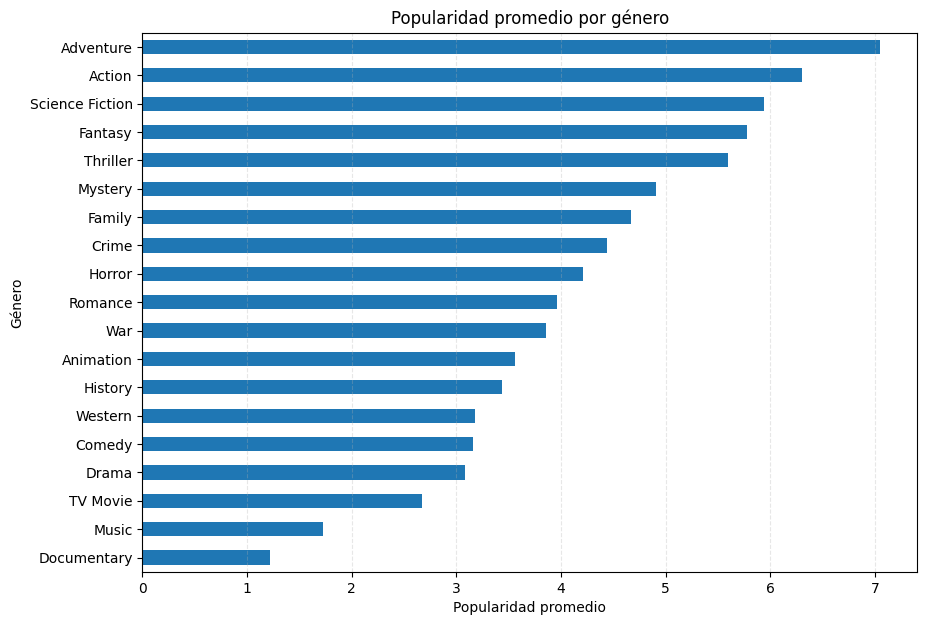

In [247]:
genre_columns = [col for col in df_valid_movies.columns if col.startswith("genre_")]

popularity_by_genre = {}

for genre_col in genre_columns:
    genre_name = genre_col.replace("genre_", "")

    popularity_by_genre[genre_name] = df_valid_movies.loc[
        df_valid_movies[genre_col] == 1,
        "popularity"
    ].mean()

popularity_by_genre = (
    pd.Series(popularity_by_genre)
    .sort_values(ascending=True)
)

plt.figure(figsize=(10, 7))
popularity_by_genre.plot(kind="barh")
plt.xlabel("Popularidad promedio")
plt.ylabel("Género")
plt.title("Popularidad promedio por género")
plt.grid(axis="x", linestyle="--", alpha=0.3)
plt.show()

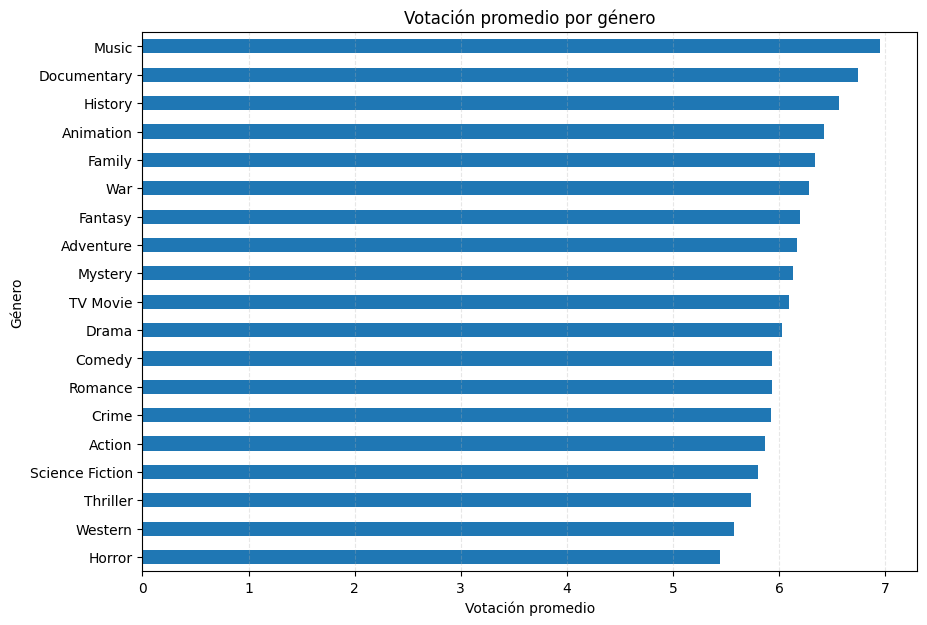

In [248]:
vote_by_genre = {}

for genre_col in genre_columns:
    genre_name = genre_col.replace("genre_", "")

    vote_by_genre[genre_name] = df_valid_movies.loc[
        df_valid_movies[genre_col] == 1,
        "vote_average"
    ].mean()

vote_by_genre = (
    pd.Series(vote_by_genre)
    .sort_values(ascending=True)
)

plt.figure(figsize=(10, 7))
vote_by_genre.plot(kind="barh")
plt.xlabel("Votación promedio")
plt.ylabel("Género")
plt.title("Votación promedio por género")
plt.grid(axis="x", linestyle="--", alpha=0.3)
plt.show()

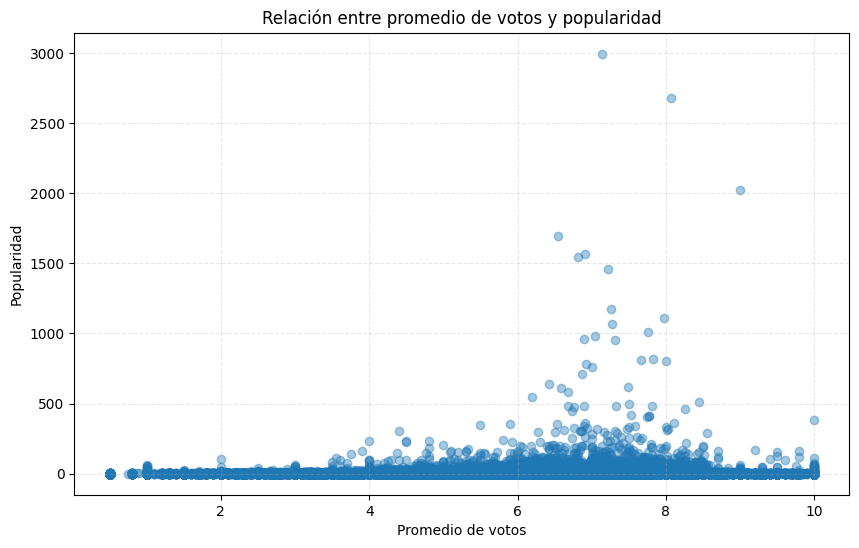

In [249]:
plt.figure(figsize=(10, 6))

plt.scatter(
    df_valid_movies["vote_average"],
    df_valid_movies["popularity"],
    alpha=0.4
)

plt.xlabel("Promedio de votos")
plt.ylabel("Popularidad")
plt.title("Relación entre promedio de votos y popularidad")
plt.grid(True, linestyle="--", alpha=0.3)
plt.show()

In [250]:
min_vote_count = df_valid_movies['vote_count'].min()
max_vote_count = df_valid_movies['vote_count'].max()

print("Valor mínimo de cantidad de votos:", min_vote_count)
print("Valor máximo de cantidad de votos:", max_vote_count)

Valor mínimo de cantidad de votos: 1
Valor máximo de cantidad de votos: 34495


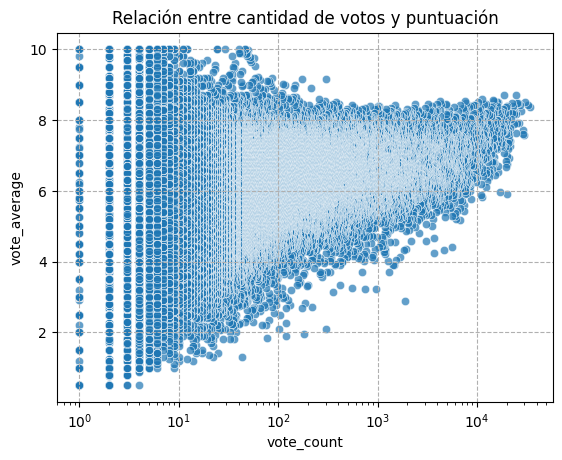

In [251]:
sns.scatterplot(
    data=df_valid_movies,
    x='vote_count',
    y='vote_average',
    alpha=0.7
)

plt.xscale('log')
plt.grid(ls='--')
plt.title('Relación entre cantidad de votos y puntuación')
plt.show()

Con este gráfico podemos observar valores extremos en películas con pocos votos pero puntuaciones altas y la dispersión va disminuyendo a medida que aumenta la cantidad de votos.

Al momento de medir el éxito, sabemos que cuantos más votos recibe una película, más estable y confiable se vuelve su puntuación promedio. Por lo cual trabajaremos con la siguiente fórmula para el cálculo:

(vc / (vc+u)) * va + (u / (vc+u)) * m

vc = vote_count

va = vote_average

u = umbral mínimo de votos para considerar el rating confiable (típicamente un percentil alto de vote_count, ejemplo el 0.90).

m  = media global de vote_average del dataset

In [252]:
df_valid_movies['release_date'].head(10)

,release_date
0,2010-07-15
1,2014-11-05
2,2008-07-16
3,2009-12-15
4,2012-04-25
5,2016-02-09
6,2018-04-25
7,1999-10-15
8,2014-07-30
9,1994-09-10


In [253]:
df_valid_movies['release_date'] = pd.to_datetime(df_valid_movies['release_date'], errors='coerce')
df_valid_movies['release_month'] = df_valid_movies['release_date'].dt.month
df_valid_movies['release_month']

,release_month
0,7
1,11
2,7
3,12
4,4
...,...
359327,8
359329,8
359330,12
359331,3


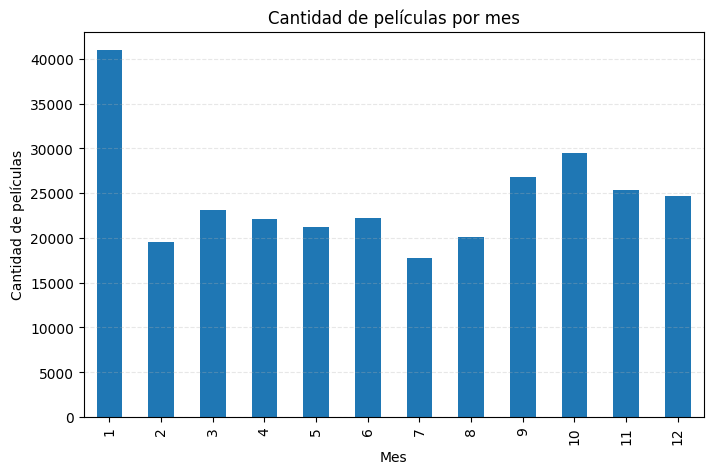

In [254]:
month_counts = df_valid_movies['release_month'].value_counts().sort_index()

plt.figure(figsize=(8, 5))
month_counts.plot(kind='bar')
plt.xlabel('Mes')
plt.ylabel('Cantidad de películas')
plt.title('Cantidad de películas por mes')
plt.grid(axis='y', linestyle='--', alpha=0.3)
plt.show()

In [255]:
df_valid_movies['release_month'].mode()[0]

np.int32(1)

In [256]:
df_valid_movies['release_year'] = df_valid_movies['release_date'].dt.year
df_valid_movies['release_year']

,release_year
0,2010
1,2014
2,2008
3,2009
4,2012
...,...
359327,2006
359329,1963
359330,1954
359331,2007


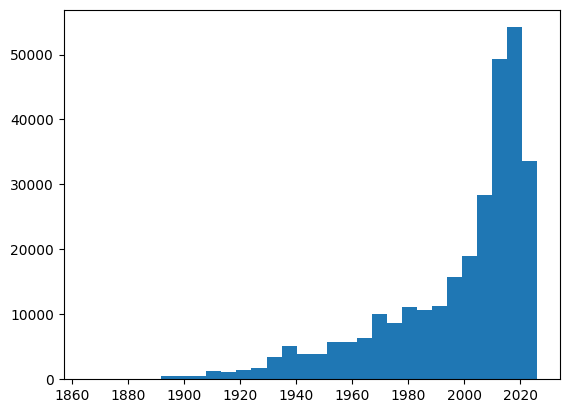

In [257]:
plt.hist(df_valid_movies['release_year'], bins=30)
plt.show()

In [258]:
df_valid_movies['release_year'].mode()[0]

np.int32(2019)

In [259]:
min_release_year = df_valid_movies['release_year'].min()
max_release_year = df_valid_movies['release_year'].max()

print("Valor mínimo de año de lanzamiento:", min_release_year)
print("Valor máximo de año de lanzamiento:", max_release_year)

Valor mínimo de año de lanzamiento: 1865
Valor máximo de año de lanzamiento: 2026


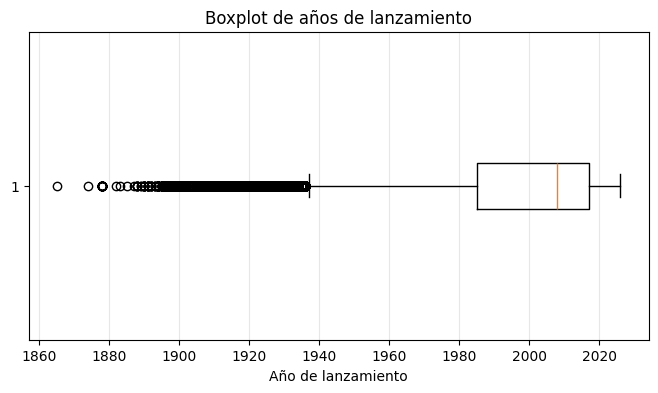

In [260]:
plt.figure(figsize=(8, 4))
plt.boxplot(df_valid_movies['release_year'], vert=False)
plt.xlabel('Año de lanzamiento')
plt.title('Boxplot de años de lanzamiento')
plt.grid(axis='x', alpha=0.3)
plt.show()

In [261]:
Q1 = df_valid_movies['release_year'].quantile(0.25)
Q3 = df_valid_movies['release_year'].quantile(0.75)

IQR = Q3 - Q1

print(f"Q1: {Q1}")
print(f"Q3: {Q3}")
print(f"IQR: {IQR}")

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

print(f"Límite inferior: {lower_bound}")
print(f"Límite superior: {upper_bound}")

outliers = df_valid_movies[
    (df_valid_movies['release_year'] < lower_bound) |
    (df_valid_movies['release_year'] > upper_bound)
]

print(f"Cantidad de outliers: {len(outliers)}")

Q1: 1985.0
Q3: 2017.0
IQR: 32.0
Límite inferior: 1937.0
Límite superior: 2065.0
Cantidad de outliers: 12226


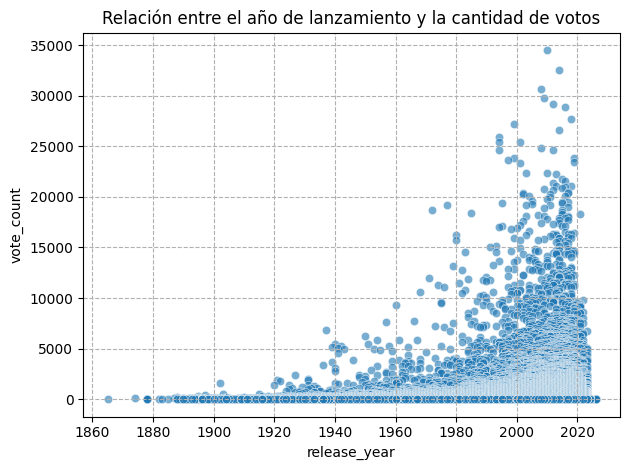

In [262]:
sns.scatterplot(data=df_valid_movies, x='release_year', y='vote_count', alpha=0.6)
plt.grid(ls='--')
plt.title('Relación entre el año de lanzamiento y la cantidad de votos')
plt.tight_layout()
plt.show()

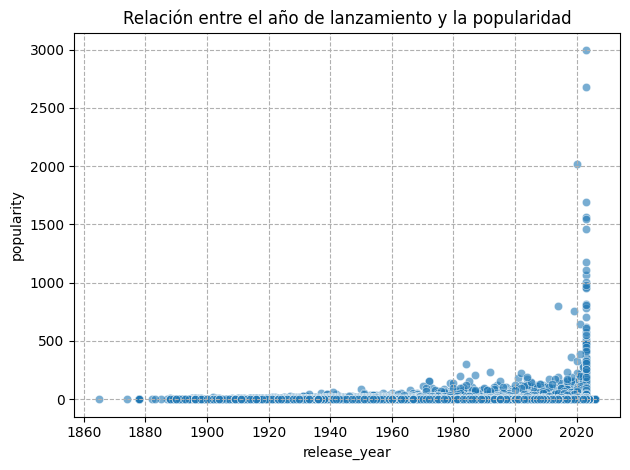

In [263]:
sns.scatterplot(data=df_valid_movies, x='release_year', y='popularity', alpha=0.6)
plt.grid(ls='--')
plt.title('Relación entre el año de lanzamiento y la popularidad')
plt.tight_layout()
plt.show()

In [264]:
u = df_valid_movies['vote_count'].quantile(0.90)
m = df_valid_movies['vote_average'].mean()

df_valid_movies['success_score'] = (
    (df_valid_movies['vote_count'] / (df_valid_movies['vote_count'] + u)) * df_valid_movies['vote_average'] +
    (u / (df_valid_movies['vote_count'] + u)) * m
)

df_valid_movies['success_score']

,success_score
0,8.360971
1,8.413718
2,8.508366
3,7.570715
4,7.707449
...,...
359327,6.130410
359329,6.172963
359330,6.087856
359331,6.002750


In [265]:
threshold = df_valid_movies['success_score'].quantile(0.75)
threshold

np.float64(6.1705849392193635)

In [266]:
df_valid_movies['success_label'] = np.where(
    df_valid_movies['success_score'] >= threshold,
    'success',
    'no_success'
)

df_valid_movies['success_label']

,success_label
0,success
1,success
2,success
3,success
4,success
...,...
359327,no_success
359329,success
359330,no_success
359331,no_success


In [267]:
success_by_year = (
    df_valid_movies
    .groupby(['release_year', 'success_label'])
    .size()
    .unstack(fill_value=0)
)

success_by_year.head()

success_label,no_success,success
release_year,,
1865,0,1
1874,1,0
1878,26,0
1882,1,0
1883,1,0


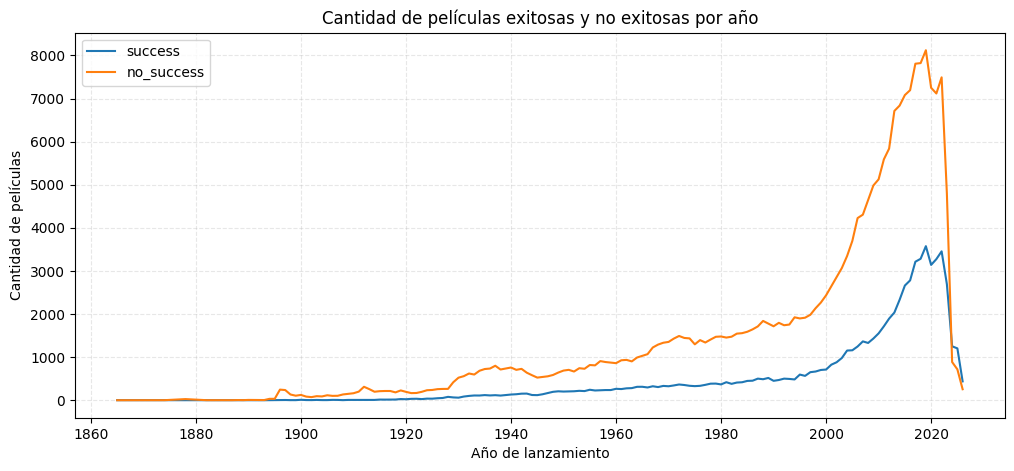

In [268]:
plt.figure(figsize=(12, 5))

plt.plot(success_by_year.index, success_by_year['success'], label='success')
plt.plot(success_by_year.index, success_by_year['no_success'], label='no_success')

plt.xlabel('Año de lanzamiento')
plt.ylabel('Cantidad de películas')
plt.title('Cantidad de películas exitosas y no exitosas por año')
plt.legend()
plt.grid(ls='--', alpha=0.3)

plt.show()

## Pre-procesamiento de datos

De antemano sabemos que las columnas `backdrop_path`, `homepage`, `poster_path` no son relevantes para nuestro problema, ya que representan links o metadata de las peliculas de la pagina web.

Por ende las sacamos sin mas analisis

In [269]:
df_valid_movies.drop(columns=["backdrop_path", "homepage", "poster_path"], inplace=True)

Hacemos el casteo de datos apropiado para unicamente trabajar con numeros en todo el problema



In [270]:
genre_cols   = [c for c in df_valid_movies.columns if c.startswith("genre_")]
num_features = ['vote_average', 'vote_count', 'popularity', 'runtime', 'release_year', 'release_month']
bin_features = ['adult'] + genre_cols
all_features = num_features + bin_features

TARGET = 'success_label'
df_model = df_valid_movies[all_features + [TARGET]].copy()
df_model['adult']  = df_model['adult'].astype(int)
df_model['target'] = (df_model[TARGET] == 'success').astype(int)

# Excluimos el
X = df_model[all_features]
y = df_model['target']

Separamos el set de prueba del set de entrenamiento.

Ademas, para el train set, distinguimos entre variables numericas y variables binarias para la seleccion de features

In [271]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Separamos en variables numericas y variables binarias
X_train_num = X_train[num_features].astype(float)
X_train_bin = X_train[bin_features].astype(int)

# Reduccion de Dimensionalidad

In [272]:
from scipy.stats import chi2_contingency, f_oneway
from sklearn.feature_selection import SelectKBest, f_classif, chi2, mutual_info_classif
from sklearn.preprocessing import MinMaxScaler, StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.decomposition import PCA

## Seleccion de features

Evaluamos la correlacion entre features numerica utilizano Correlacion de Pearson

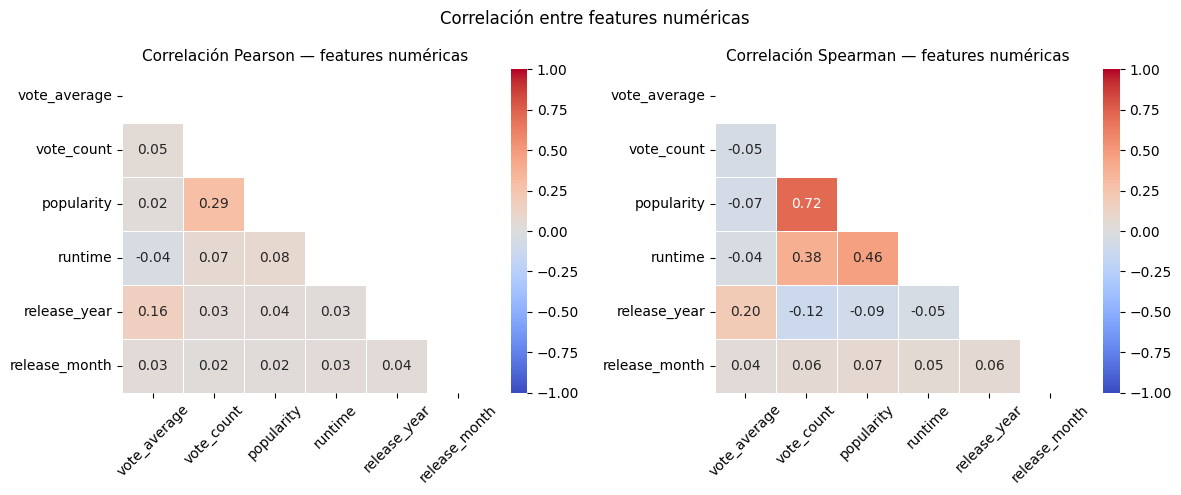

In [273]:
corr_pearson  = X_train_num.corr(method='pearson')
corr_spearman = X_train_num.corr(method='spearman')

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

for ax, corr, title in zip(
    axes,
    [corr_pearson, corr_spearman],
    ['Pearson', 'Spearman']
):
    mask = np.triu(np.ones_like(corr, dtype=bool))
    sns.heatmap(
        corr, annot=True, fmt=".2f",
        cmap="coolwarm", vmin=-1, vmax=1,
        center=0, linewidths=0.5,
        mask=mask, ax=ax
    )
    ax.set_title(f"Correlación {title} — features numéricas", fontsize=11)
    ax.tick_params(axis='x', rotation=45)

plt.suptitle("Correlación entre features numéricas", fontsize=12)
plt.tight_layout()
plt.show()

Analizamos el poder predictivo entre las v. numéricas y la target categórica con ANOVA

,ANOVA F Score,p-value
vote_average,119367.30,0.0000
vote_count,4785.47,0.0000
popularity,3475.64,0.0000
release_year,3038.93,0.0000
runtime,847.89,0.0000
release_month,420.21,0.0000


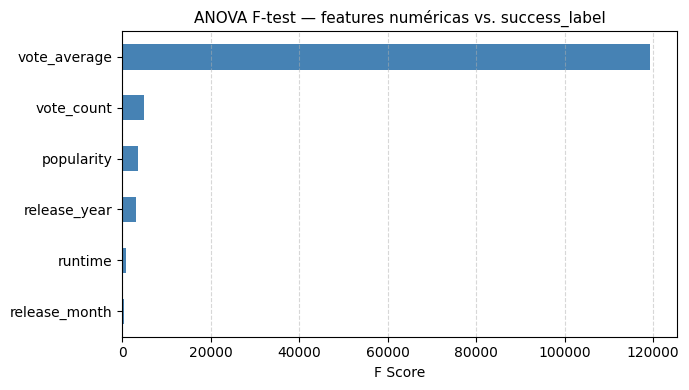

In [274]:
import jinja2

selector_anova = SelectKBest(score_func=f_classif, k='all')
selector_anova.fit(X_train_num, y_train)

anova_result = pd.DataFrame({
    'ANOVA F Score': selector_anova.scores_,
    'p-value':       selector_anova.pvalues_
}, index=num_features).sort_values('ANOVA F Score', ascending=False)

display(anova_result.style.format({'ANOVA F Score': '{:.2f}', 'p-value': '{:.4f}'}))

fig, ax = plt.subplots(figsize=(7, 4))
anova_result['ANOVA F Score'].sort_values().plot.barh(ax=ax, color='steelblue')
ax.set_title("ANOVA F-test — features numéricas vs. success_label", fontsize=11)
ax.set_xlabel("F Score")
ax.grid(axis='x', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

Analizamos poder predictivo entre las v. categóricas y la target categórica con Chi2

,Chi2 Score,p-value
genre_Music,877.12,0.0000
genre_Horror,656.80,0.0000
genre_Animation,569.70,0.0000
genre_Family,543.15,0.0000
genre_Documentary,468.75,0.0000
genre_History,411.01,0.0000
genre_Adventure,408.78,0.0000
genre_Fantasy,322.90,0.0000
genre_Western,117.81,0.0000
genre_War,116.49,0.0000


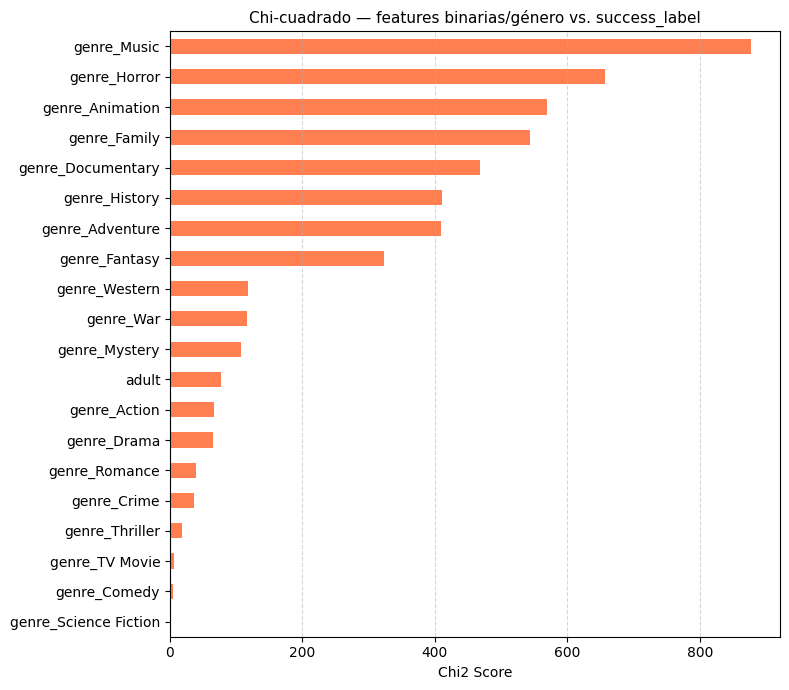

In [275]:
selector_chi2 = SelectKBest(score_func=chi2, k='all')
selector_chi2.fit(X_train_bin, y_train)

chi2_result = pd.DataFrame({
    'Chi2 Score': selector_chi2.scores_,
    'p-value':    selector_chi2.pvalues_
}, index=bin_features).sort_values('Chi2 Score', ascending=False)

display(chi2_result.style.format({'Chi2 Score': '{:.2f}', 'p-value': '{:.4f}'}))

fig, ax = plt.subplots(figsize=(8, 7))
chi2_result['Chi2 Score'].sort_values().plot.barh(ax=ax, color='coral')
ax.set_title("Chi-cuadrado — features binarias/género vs. success_label", fontsize=11)
ax.set_xlabel("Chi2 Score")
ax.grid(axis='x', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

,MI Score
vote_average,0.4270
vote_count,0.0557
popularity,0.0423
runtime,0.0150
release_year,0.0126
release_month,0.0036
genre_Music,0.0019
genre_Horror,0.0017
genre_Animation,0.0012
genre_Documentary,0.0012


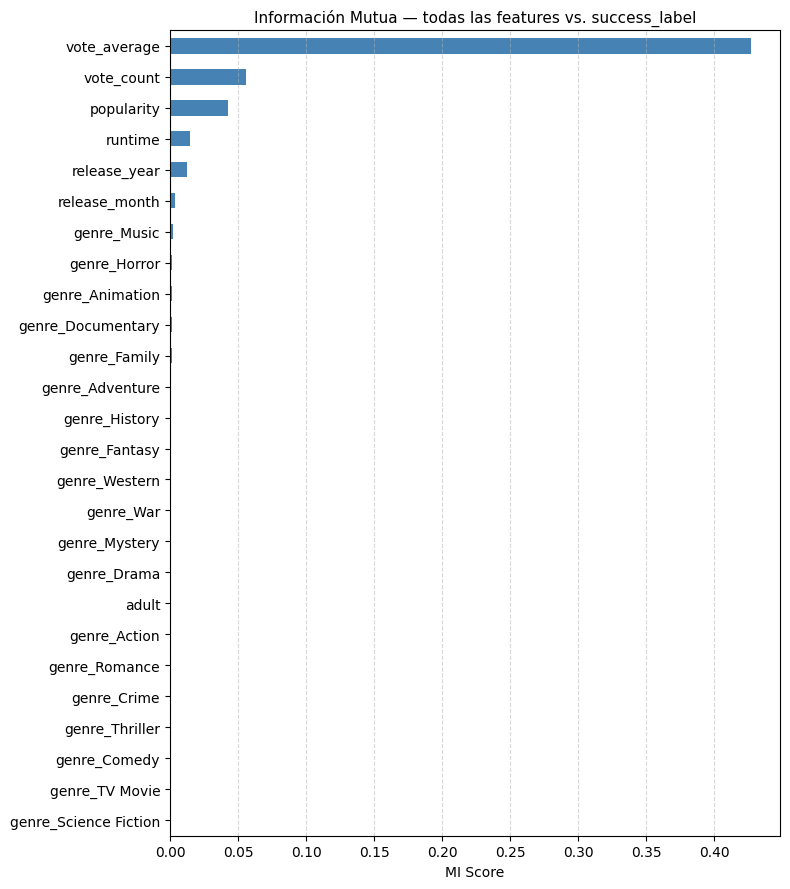

In [276]:
mi_num = mutual_info_classif(X_train_num, y_train, discrete_features=False, random_state=42)

mi_bin_vals = mutual_info_classif(X_train_bin, y_train, discrete_features=True, random_state=42)

mi_all = pd.concat([
    pd.Series(mi_num, index=num_features),
    pd.Series(mi_bin_vals, index=bin_features)
])

mi_result = mi_all.sort_values(ascending=False).rename('MI Score')
display(mi_result.to_frame().style.format({'MI Score': '{:.4f}'}))

fig, ax = plt.subplots(figsize=(8, 9))
mi_result.sort_values().plot.barh(ax=ax, color='steelblue')
ax.set_title("Información Mutua — todas las features vs. success_label", fontsize=11)
ax.set_xlabel("MI Score")
ax.grid(axis='x', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

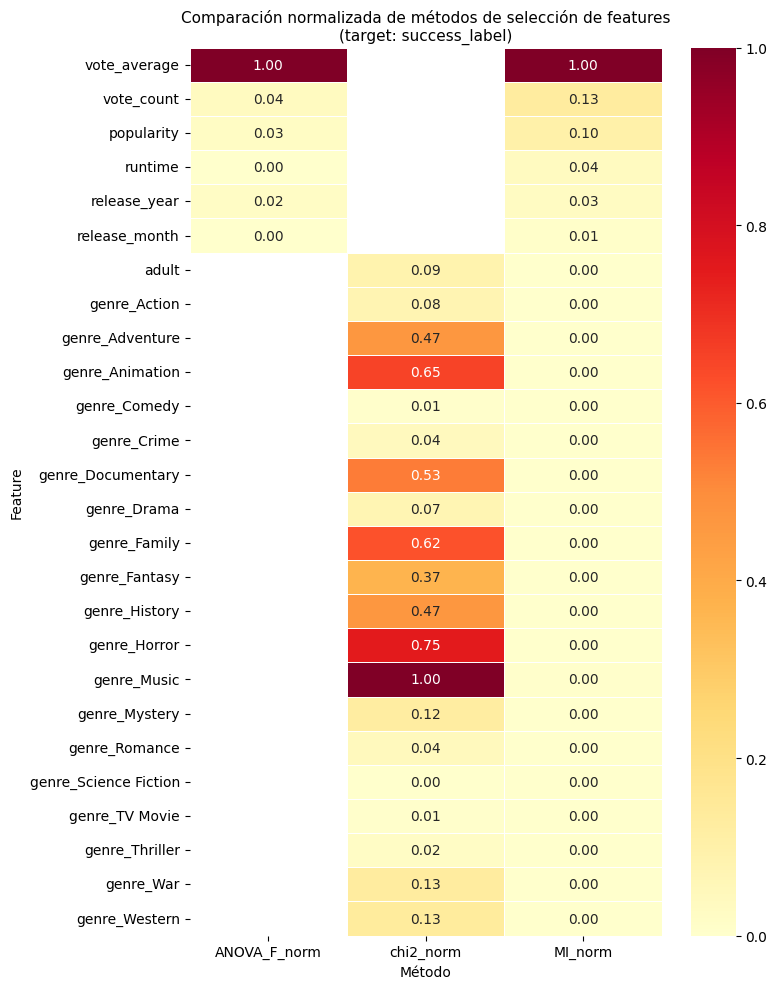

In [277]:
comparison_df = pd.DataFrame(index=all_features)

anova_norm = MinMaxScaler().fit_transform(
    pd.Series(selector_anova.scores_, index=num_features).values.reshape(-1, 1)
).flatten()
comparison_df['ANOVA_F_norm'] = pd.Series(anova_norm, index=num_features)

chi2_norm = MinMaxScaler().fit_transform(
    pd.Series(selector_chi2.scores_, index=bin_features).values.reshape(-1, 1)
).flatten()
comparison_df['chi2_norm'] = pd.Series(chi2_norm, index=bin_features)


mi_norm = MinMaxScaler().fit_transform(mi_all.values.reshape(-1, 1)).flatten()
comparison_df['MI_norm'] = pd.Series(mi_norm, index=all_features)

fig, ax = plt.subplots(figsize=(8, 10))
sns.heatmap(
    comparison_df.astype(float),
    annot=True, fmt=".2f",
    cmap="YlOrRd", vmin=0, vmax=1,
    linewidths=0.5, ax=ax
)
ax.set_title(
    "Comparación normalizada de métodos de selección de features\n(target: success_label)",
    fontsize=11
)
ax.set_xlabel("Método")
ax.set_ylabel("Feature")
plt.tight_layout()
plt.show()

A partir de los métodos de filtro aplicados, identificamos:

**Features más informativas** (con alta puntuación en ANOVA, chi2 e Informacion Mutua):
- `vote_average` y `vote_count`: Muy relevantes. Tiene sentido dado que el target `success_score` se construyó a partir de ellas).
- `popularity`: Fuerte asociación con el éxito.  Las películas populares tienden a recibir más y mejores votos.
- `runtime`: Correlación moderada; películas más largas (>90 min) tienden a ser mejor valoradas.
- Géneros como `genre_Documentary` y `genre_Drama` muestran mayor Informacion Mutua con el target.

**Features de menor relevancia:**
- Géneros con muy baja ocurrencia (`genre_TV Movie`, `genre_Western`) tienen MI $\approx$ 0.
- `adult`: Muy poca variabilidad; la gran mayoría de películas son no-adultas.
- `release_month`: Débil asociación con el éxito.

Aplicamos un umbral de **MI ≥ 0.005** para eliminar features con mínima capacidad predictiva antes de aplicar PCA.

In [278]:
THRESHOLD = 0.005
selected_features = [f for f in all_features if mi_all[f] >= THRESHOLD]
dropped_features = [f for f in all_features if f not in selected_features]

print(f"Cant features originales {len(all_features)}")
print(f"Cant features seleccionadas (MI >= {THRESHOLD}): {len(selected_features)}")
print(f"Cant Features eliminadas: {len(dropped_features)}")

if dropped_features:
    print(f"\nFeatures eliminadas: {dropped_features}")

X_train_sel = X_train[selected_features]
X_test_sel  = X_test[selected_features]

Cant features originales 26
Cant features seleccionadas (MI >= 0.005): 5
Cant Features eliminadas: 21

Features eliminadas: ['release_month', 'adult', 'genre_Action', 'genre_Adventure', 'genre_Animation', 'genre_Comedy', 'genre_Crime', 'genre_Documentary', 'genre_Drama', 'genre_Family', 'genre_Fantasy', 'genre_History', 'genre_Horror', 'genre_Music', 'genre_Mystery', 'genre_Romance', 'genre_Science Fiction', 'genre_TV Movie', 'genre_Thriller', 'genre_War', 'genre_Western']


## PCA

In [279]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_sel)
X_test_scaled = scaler.transform(X_test_sel)

pca = PCA(n_components=2)
pca.fit(X_train_scaled)

loadings = pd.DataFrame(
    pca.components_.T,
    columns=['PC1', 'PC2'],
    index=selected_features
)
loadings

,PC1,PC2
vote_average,0.213264,0.687262
vote_count,0.642332,-0.165858
popularity,0.640036,-0.198527
runtime,0.262848,-0.266101
release_year,0.251383,0.624451


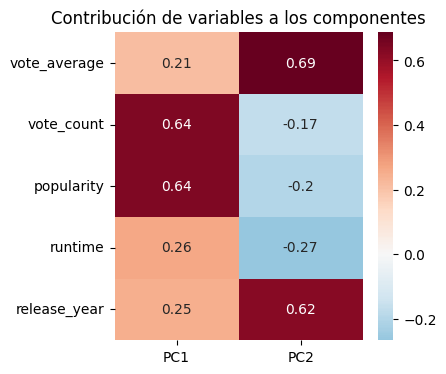

In [280]:
plt.figure(figsize=(4,4))
sns.heatmap(
    loadings,
    annot=True,
    cmap='RdBu_r',
    center=0
)
plt.title("Contribución de variables a los componentes")
plt.show()

Paso 1) Contribuciones porcentuales por componente

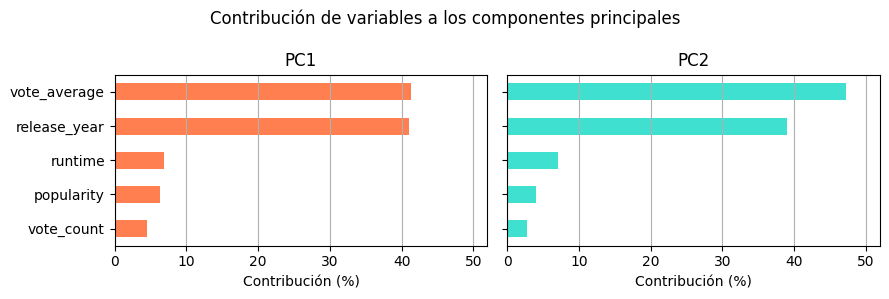

In [281]:
# Contribuciones porcentuales
contrib = (loadings**2)
contrib = contrib.div(contrib.sum(axis=0), axis=1) * 100

fig, ax = plt.subplots(1, 2, figsize=(9, 3), sharey=True)

# PC1
contrib["PC1"].sort_values().plot.barh(ax=ax[0], color='coral')
ax[0].set_title("PC1")
ax[0].set_xlabel("Contribución (%)")
ax[0].grid(axis='x')

# PC2
contrib["PC2"].sort_values().plot.barh(ax=ax[1], color='turquoise')
ax[1].set_title("PC2")
ax[1].set_xlabel("Contribución (%)")
ax[1].grid(axis='x')

# escala
max_val = contrib[["PC1", "PC2"]].max().max()
ax[0].set_xlim(0, max_val * 1.1)
ax[1].set_xlim(0, max_val * 1.1)

plt.suptitle("Contribución de variables a los componentes principales")
plt.tight_layout()
plt.show()

Paso 2) Calculamos los datos proyectados sobre los ejes principales.

In [282]:
def plot_biplot(df, loadings, feature_names, target_col=None, top_n=10, scale=5):
    """Biplot: proyección PCA con vectores de carga de las top_n features."""
    colors = ["#008392", "#ff777c"]
    target_labels = ['no_success', 'success']

    # Sample para visualizar mejor ante un dataset grande
    df_sample = df.sample(min(5000, len(df)), random_state=42)

    plt.figure(figsize=(10, 8))

    if target_col is None:
        plt.scatter(df_sample["PC1"], df_sample["PC2"], alpha=0.4, s=5, color=colors[0])
    else:
        for val, label, color in zip([0, 1], target_labels, colors):
            mask = df_sample[target_col] == val
            plt.scatter(
                df_sample.loc[mask, "PC1"],
                df_sample.loc[mask, "PC2"],
                alpha=0.4, s=5, color=color, label=label
            )
        plt.legend(markerscale=6, fontsize=10)

    loading_magnitude = (loadings ** 2).sum(axis=1)
    top_features = loading_magnitude.nlargest(top_n).index

    for feature in top_features:
        dx = loadings.loc[feature, 'PC1'] * scale
        dy = loadings.loc[feature, 'PC2'] * scale
        plt.arrow(0, 0, dx, dy, head_width=0.08, color='black', alpha=0.75)
        plt.text(dx * 1.08, dy * 1.08, feature, fontsize=8, ha='center')

    exp_var = pca.explained_variance_ratio_
    plt.xlabel(f"PC1 ({exp_var[0]:.1%} varianza explicada)", fontsize=11)
    plt.ylabel(f"PC2 ({exp_var[1]:.1%} varianza explicada)", fontsize=11)
    plt.title("Biplot — Proyección PCA con cargas factoriales (top features)", fontsize=12)
    plt.axhline(0, color='gray', linewidth=0.5)
    plt.axvline(0, color='gray', linewidth=0.5)
    plt.grid(linestyle='--', alpha=0.3)
    plt.tight_layout()
    plt.show()

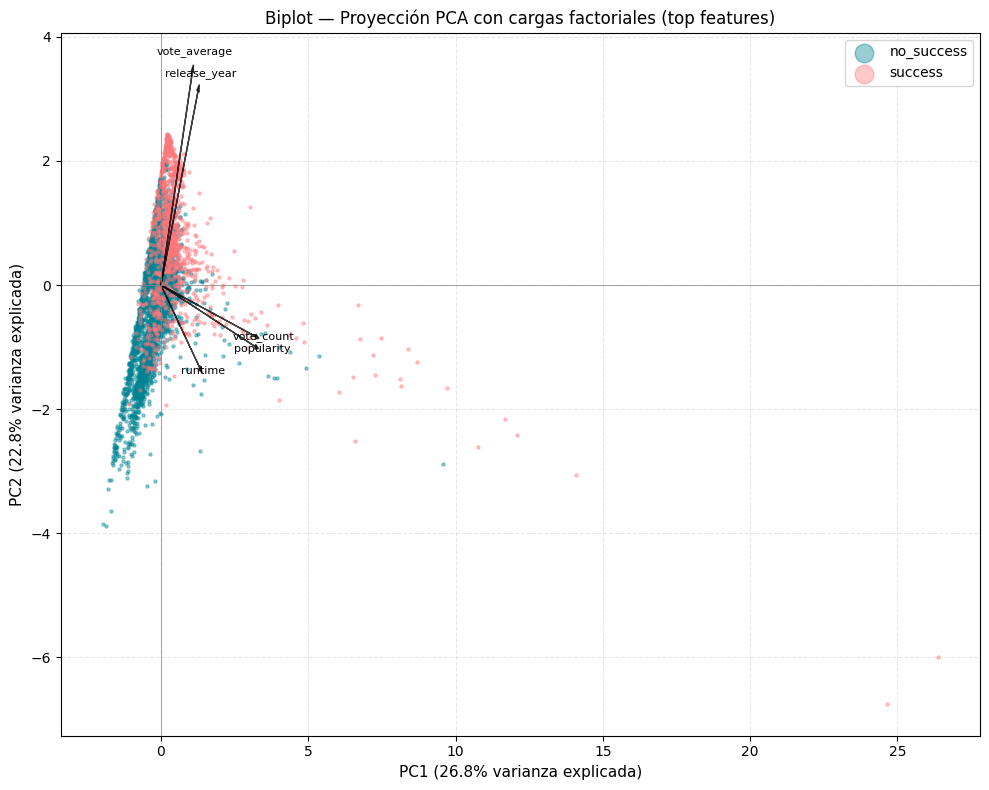

In [283]:
X_train_scores = pca.transform(X_train_scaled)
df_train_pca = pd.DataFrame(X_train_scores, columns=['PC1', 'PC2'])
df_train_pca['target'] = y_train.values

plot_biplot(df_train_pca, loadings, selected_features, target_col='target')

Paso 3) Preparamos los datasets de train y test con los datos transformados

In [284]:
df_train_pca = pd.DataFrame(X_train_scores, columns=['PC1', 'PC2'])
df_train_pca['target'] = y_train.values

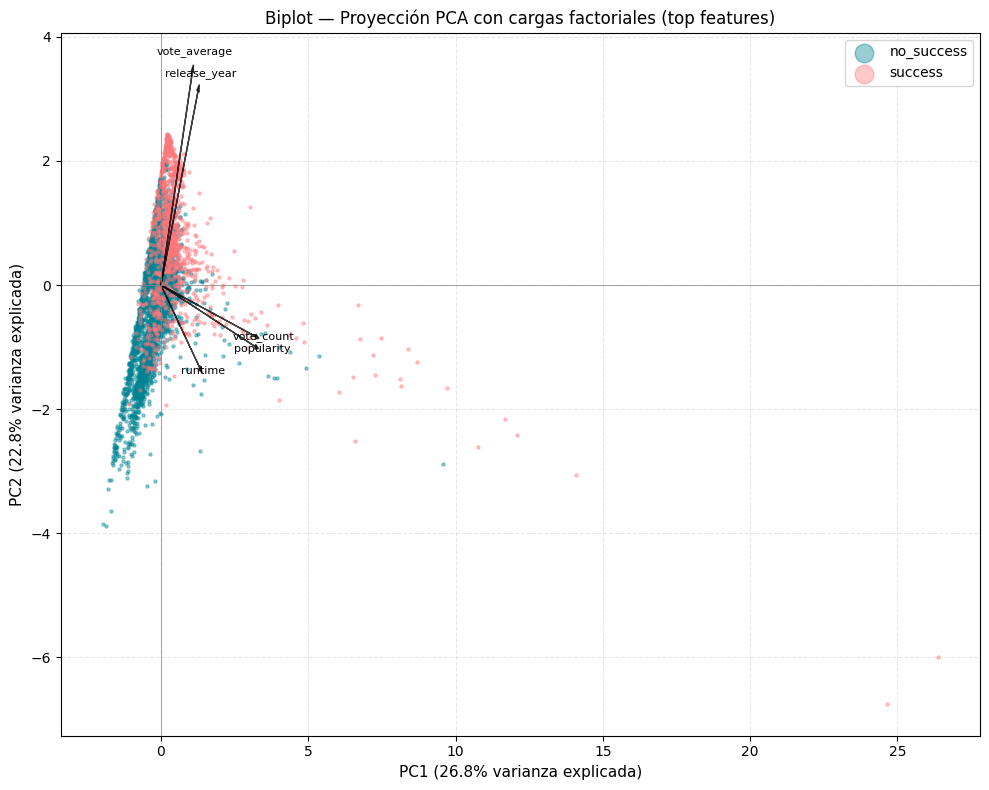

In [285]:
plot_biplot(df_train_pca, loadings, selected_features, target_col="target")

In [286]:
# Luego de entrenado el modelo aplicamos PCA en el dataset de test para poder evaluarlo.
# El dataset de test tiene que tener el mismo formato (columnas) que el de train:

X_test_scores = pca.transform(X_test_scaled) # scores
df_test_pca = pd.DataFrame(X_test_scores, columns=['PC1', 'PC2'])
df_test_pca['target'] = y_test.values
df_test_pca.head()

,PC1,PC2,target
0,-0.123539,-0.168775,0
1,-0.646921,-1.524572,0
2,2.471040,-0.262560,1
3,0.019907,1.019150,1
4,0.500411,-0.473754,0


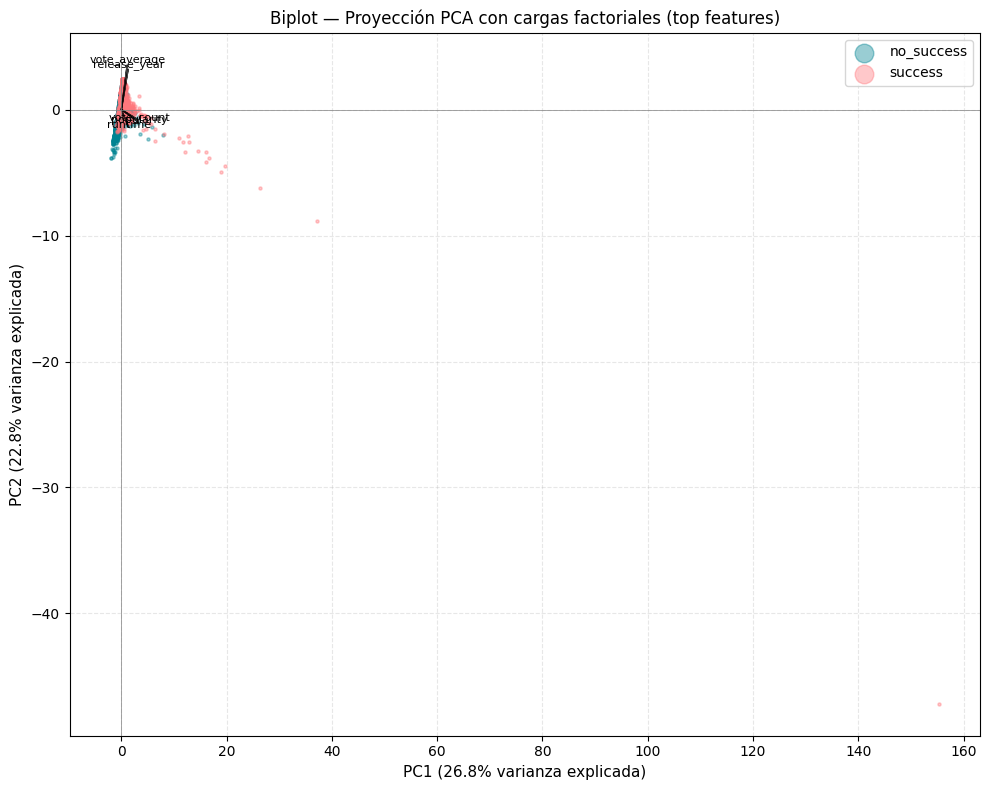

In [287]:
plot_biplot(df_test_pca, loadings, selected_features, target_col="target")